# Health Data Visualization Report

### Morbidity Profile Analysis — Open Health Data

**Dataset:** `Perfil_de_morbilidad_20260906.csv` — Morbidity Profile dataset obtained from the open data repository (Digital, 2026).

**Tools used:** Google Colab, Python 3, pandas, matplotlib.

**Date:** September 6, 2026


---

## Table of contents
1. Introduction and objectives
2. Data loading
3. Initial data exploration
4. Data cleaning and transformation
5. Exploratory data analysis (findings)
6. Data visualization
7. Conclusions
8. Final Health Data Visualization Report (variables, relationships, graphical interpretation, findings)
9. Reproducibility and ethics statement
10. References


## 1. Introduction and objectives

The purpose of this notebook is to perform a complete, reproducible data analysis workflow on a real, openly published health dataset, in order to demonstrate a health-related phenomenon through data visualization.

For this activity, the **Morbidity Profile** dataset was selected. It contains hospital-level records describing, for each patient encounter, the diagnosis (ICD-10 code and name), the functional unit that provided the care, the discharge destination, the patient's age, and the reporting year.

The specific objectives of this notebook are:

- To clean and transform a raw, partially structured dataset into an analysis-ready table.
- To select at least two relevant variables and analyze the relationship between them.
- To build clear visualizations that evidence this relationship.
- To document every processing decision in technical English so that the workflow is transparent and reproducible for any engineering team, regardless of native language.
- To discuss the ethical implications of working with hospital morbidity data (e.g., absence of a patient identifier, anonymization, and the limits this places on interpretation).


**Note:** for this activity, the *Perfil de Morbilidad* (Morbidity Profile) dataset, published by E.S.E. Hospital Universitario Hernando Moncaleano Perdomo (Neiva, Huila), was selected. Instead of manually downloading and uploading the file, the data is retrieved directly and reproducibly from the Socrata Open Data API (SODA) exposed by the open data repository. This avoids a manual, non-reproducible step and guarantees that anyone re-running this notebook gets the same live dataset.

In [111]:
# Import pandas, the main library used for tabular data manipulation
import pandas as pd

# Direct SODA (Socrata Open Data API) endpoint for the "Perfil de Morbilidad" dataset.
# NOTE: the 4x4 resource id used by the API (5c4n-qdbv) is NOT the same id shown
# in the dataset's page URL (5r4m-umt6); the API id was confirmed from the
# dataset's own metadata/catalog page.
# "$limit=500000" is required because Socrata's API returns only 1,000 rows by default.
url = "https://www.datos.gov.co/resource/5c4n-qdbv.csv?$limit=500000"

# Read the dataset directly from the API into a DataFrame called "df"
df = pd.read_csv(url)

# The Socrata API returns column names in lowercase snake_case
# (e.g. "cidigo_cie_10" instead of "CIDIGO CIE-10"). The dictionary below
# maps each API field name back to the original, human-readable column
# names used throughout the rest of this notebook, so no other cell needs
# to be modified.
api_to_original_columns = {
    "cidigo_cie_10": "CIDIGO CIE-10",
    "nombre_del_diagnostico": "NOMBRE DEL DIAGNOSTICO",
    "unidad_funcional": "UNIDAD FUNCIONAL",
    "destino_al_egreso": "DESTINO AL EGRESO",
    "edad_de_atencion_a_os": "EDAD DE ATENCION (AÑOS)",
    "a_o_reportado": "AÑO REPORTADO",
}

# Apply the rename so column names match the rest of the notebook exactly
df = df.rename(columns=api_to_original_columns)

# Print the shape (rows, columns) to get a first sense of the dataset size
print(df.shape)

# Display the first 5 rows to visually inspect the raw structure of the data
df.head()

(375276, 6)


,CIDIGO CIE-10,NOMBRE DEL DIAGNOSTICO,UNIDAD FUNCIONAL,DESTINO AL EGRESO,EDAD DE ATENCION (AÑOS),AÑO REPORTADO
0,A000,"COLERA DEBIDO A VIBRIO CHOLERAE O1, BIOTIPO CH...",CONSULTA EXTERNA,SALIDA,39,2017
1,A000,"COLERA DEBIDO A VIBRIO CHOLERAE O1, BIOTIPO CH...",CONSULTA EXTERNA,SALIDA,44,2017
2,A010,FIEBRE TIFOIDEA,CONSULTA EXTERNA,SALIDA,28,2017
3,A010,FIEBRE TIFOIDEA,CONSULTA EXTERNA,SALIDA,76,2017
4,A010,FIEBRE TIFOIDEA,CONSULTA EXTERNA,SALIDA,50,2017


In [112]:
# --- Diagnostic fallback (optional) ---
# If the cell above raises an error (e.g. the API endpoint changes or is
# temporarily unavailable), uncomment the two lines below to fall back to
# the manual upload widget in Google Colab:
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('Perfil_de_morbilidad_20260906.csv')

**Interpretation:** the dataset contains 375,276 rows and 6 columns. A typo was detected in the diagnosis-code column header (`CIDIGO CIE-10` instead of `CODIGO CIE-10`), and the reporting-year column shows a formatting issue that must be verified and corrected.

## 3. Initial data exploration

In [113]:
# Check for null values and data types;
# df.info() prints column names, non-null counts and dtypes
df.info()

# Print a header to clearly separate the next block of output
print("\nNull values per column: ")

# Sum the boolean mask returned by isnull() for each column,
# giving the exact count of missing values per column
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375276 entries, 0 to 375275
Data columns (total 6 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   CIDIGO CIE-10            375276 non-null  object
 1   NOMBRE DEL DIAGNOSTICO   375276 non-null  object
 2   UNIDAD FUNCIONAL         375276 non-null  object
 3   DESTINO AL EGRESO        375276 non-null  object
 4   EDAD DE ATENCION (AÑOS)  375276 non-null  int64 
 5   AÑO REPORTADO            375276 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 17.2+ MB

Null values per column: 
CIDIGO CIE-10              0
NOMBRE DEL DIAGNOSTICO     0
UNIDAD FUNCIONAL           0
DESTINO AL EGRESO          0
EDAD DE ATENCION (AÑOS)    0
AÑO REPORTADO              0
dtype: int64


**Interpretation:** null values were checked for every column and none were found. However, the *reporting year* column is stored as text (`object`) and must be converted to a numeric type; the `int64` dtype used for the age column wastes memory for a small range of values; and it is advisable to cast the diagnosis code to `string`, which uses less memory and avoids ambiguity.

In [114]:
# Print the unique values of the reporting-year column to inspect its format
print(df['AÑO REPORTADO'].unique())

[2017 2018 2019 2020 2024 2021 2022 2023]


**Interpretation:** a formatting error is found in the numeric values (years contain thousands separators, e.g. `"2,017"`), which is why the column was not recognized as numeric.

In [115]:
# Loop over the two categorical columns that need frequency inspection
for col in ['UNIDAD FUNCIONAL', 'DESTINO AL EGRESO']:
  # Print a header showing the column name and its list of unique values
  print(f'\n--- {col}({df[col].unique()} unique values) ---')
  # Print the frequency table (value counts) for the current column
  print(df[col].value_counts())


--- UNIDAD FUNCIONAL(['CONSULTA EXTERNA' 'HOSPITALIZACION SEPTIMO PISO'
 'HOSPITALIZACION INFECTOLOGIA PEDIATRICA'
 'HOSPITALIZACION MEDICINA INTERNA' 'OBSERVACION ADULTO URGENCIAS'
 'OBSERVACION PEDIATRICA URGENCIAS'
 'ATENCION INICIAL DE URGENCIAS ADULTOS'
 'ATENCION INICIAL URGENCIAS PEDIATRIA' 'CLINICA DE HERIDAS'
 'HOSPITALIZACION CIRUGIA' 'HOSPITALIZACION INFECTOLOGIA SEXTO PISO'
 'CUIDADO INTENSIVO ADULTO' 'CUIDADO INTENSIVO PEDIATRICO' 'QUIROFANOS'
 'SALA DE PARTOS' 'HOSPITALIZACION ONCOLOGIA'
 'HOSPITALIZACION GINECO OBSTETRICIA' 'HOSPITALIZACION PEDIATRIA'
 'UNIDAD BASICA NEONATAL' 'HOSPITALIZACION NEUROCIRUGIA'
 'CUIDADO INTENSIVO OBSTETRICO' 'UCI NEONATAL' 'UNIDAD CARDIOVASCULAR'
 'HOSPITALIZACION SALUD MENTAL' 'RECUPERACION CIRUGIA' 'AD CARDIOVASCULAR'
 'UNIDAD NEONATAL' 'RADIOTERAPIA' 'HEALING THE CHILDREN'
 'PROGRAMA MADRE CANGURO' 'UNIDAD DE CANCER'] unique values) ---
UNIDAD FUNCIONAL
CONSULTA EXTERNA                           132260
OBSERVACION ADULTO URGENCIAS      

## Outliers and redundant categories detected

By analyzing the frequencies and category names above, the following anomalies were identified. They artificially inflate the number of categories (especially the 94 values found in *Discharge Destination*):

**Column: Functional Unit**
- Synonym redundancy (different names for the same unit): `UNIDAD CARDIOVASCULAR` (2,214) vs. `AD CARDIOVASCULAR` (169) → should be unified.
- `UNIDAD NEONATAL` (1,561) vs. `UNIDAD BASICA NEONATAL` (1,991) → it must be validated whether these need to remain operationally separate.
- Low-frequency records (isolated cases): `PROGRAMA MADRE CANGURO` (1 case) and `UNIDAD DE CANCER` (1 case). If these are data-entry errors, they should be moved to their main services (Pediatrics/Oncology).

**Column: Discharge Destination**
- Concept-mixing outliers (the main error): `FALLECIDO` (deceased) and `REMITIDO` (referred) appear at the bottom of the list with very low frequencies (probably a few records use this exact wording), while `MORGUE` (5,973) and `REFERENCIA` (17,564) are the dominant labels for those same real-world events.
- 88 of the 94 unique values are **not** final discharge destinations but names of medical specialties (e.g., `MEDICINA INTERNA`, `PEDIATRIA`, `ANESTESIA CARDIOTORAXICA`). This happens because the system recorded an internal ward/service transfer instead of an actual hospital discharge.

It must therefore be verified whether these categories require separation before further analysis, which is addressed in the transformation section below.

In [116]:
# Convert the age column to numeric, forcing invalid values to NaN ("coerce")
edad_numerica = pd.to_numeric(df["EDAD DE ATENCION (AÑOS)"], errors="coerce")

# Print descriptive statistics (min, max, mean, quartiles, etc.)
print(edad_numerica.describe())

# Count how many rows could not be converted to a valid number
print("Rows that could not be converted to numeric:", edad_numerica.isnull().sum())

count    375276.000000
mean         36.178722
std          25.228019
min           0.000000
25%          15.000000
50%          33.000000
75%          57.000000
max         106.000000
Name: EDAD DE ATENCION (AÑOS), dtype: float64
Rows that could not be converted to numeric: 0


**Interpretation:** the values are correct; `.describe()` shows no impossible minimum or maximum ages, so no outliers are detected in this variable.

In [117]:
# Count the exact number of fully duplicated rows (all columns identical)
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 167043


**Interpretation:** `df.duplicated()` is used to find the exact number of rows sharing identical values across all columns. Although duplicate rows exist, several patients could legitimately share the same diagnosis, unit, age, year, and destination; since the dataset does not include a patient identifier, it is not possible to reliably determine whether these are data-entry duplicates or genuinely identical clinical cases.

## 4. Data cleaning and transformation

In [118]:
# Fix the typo detected in the diagnosis-code column header
df = df.rename(columns={"CIDIGO CIE-10": "CODIGO CIE-10"})

In [119]:
# Reporting year: this column arrives differently depending on the data source.
# - When loaded from the SODA API, it is already numeric (no formatting issues).
# - When loaded from the manually-uploaded CSV, it is stored as text with a
#   thousands-separator comma (e.g. "2,017") and must be cleaned first.
# The check below makes the cell work correctly with either source.
if df["AÑO REPORTADO"].dtype == "object":
    # Only text columns have a .str accessor: remove the comma before converting
    df["AÑO REPORTADO"] = df["AÑO REPORTADO"].str.replace(",", "")

# Convert to numeric (safe for both text and already-numeric input) and
# downcast to the smallest integer subtype that fits the data
df["AÑO REPORTADO"] = pd.to_numeric(df["AÑO REPORTADO"], downcast="integer")

# Age: convert to numeric and downcast to the smallest possible integer subtype
df["EDAD DE ATENCION (AÑOS)"] = pd.to_numeric(df["EDAD DE ATENCION (AÑOS)"], downcast="integer")

# Verify that both columns now have the expected numeric dtypes
print(df[["AÑO REPORTADO", "EDAD DE ATENCION (AÑOS)"]].dtypes)

AÑO REPORTADO              int16
EDAD DE ATENCION (AÑOS)     int8
dtype: object


In [120]:
# List of text columns that need whitespace trimming and case normalization
cols_texto = ["CODIGO CIE-10", "NOMBRE DEL DIAGNOSTICO", "UNIDAD FUNCIONAL", "DESTINO AL EGRESO"]

# For each text column: strip leading/trailing spaces and force uppercase,
# so that values such as " Fiebre" and "FIEBRE " are treated as the same category
for col in cols_texto:
    df[col] = df[col].str.strip().str.upper()

In [121]:
# Print the final list of column names to confirm the header fix took effect
print(df.columns.tolist())

['CODIGO CIE-10', 'NOMBRE DEL DIAGNOSTICO', 'UNIDAD FUNCIONAL', 'DESTINO AL EGRESO', 'EDAD DE ATENCION (AÑOS)', 'AÑO REPORTADO']


**Interpretation:** age and year are converted to integer types and the thousands-separator comma is removed from the year column; text columns are cleaned by trimming whitespace and unifying letter case; and the misspelled column name `CIDIGO` is corrected to `CODIGO`.

In [122]:
# Unify the synonym found for the cardiovascular unit into a single category
df["UNIDAD FUNCIONAL"] = df["UNIDAD FUNCIONAL"].replace({
    "AD CARDIOVASCULAR": "UNIDAD CARDIOVASCULAR"
})

**Decision:** `UNIDAD NEONATAL` vs. `UNIDAD BASICA NEONATAL` are kept as separate categories, since they may represent a real difference in the level of care complexity rather than a data-entry inconsistency.

In [123]:
# Dictionary mapping the raw "Discharge Destination" values that ARE
# genuine final outcomes to a standardized label
destinos_reales = {
    "SALIDA": "SALIDA",                                   # regular discharge
    "MORGUE": "FALLECIDO",                                 # morgue -> deceased
    "FALLECIDO": "FALLECIDO",                              # already labeled as deceased
    "REFERENCIA": "REMITIDO",                              # referral -> referred
    "REMITIDO": "REMITIDO",                                # already labeled as referred
    "RETIRO VOLUNTARIO": "RETIRO VOLUNTARIO",              # voluntary withdrawal
    "FUGA": "FUGA",                                        # patient escape/absconding
    "HOSPITALIZACION EN CASA": "HOSPITALIZACION EN CASA",  # home hospitalization
}

# New column: clean final destination.
# Any raw value found in the dictionary above is mapped to its standardized label;
# anything else (the 88 specialty names) is filled with "TRASLADO A SERVICIO"
# (internal transfer to another service), since those are not real discharges
df["DESTINO_FINAL"] = df["DESTINO AL EGRESO"].map(destinos_reales).fillna("TRASLADO A SERVICIO")

# New column: internal transfer service.
# Keeps the original specialty name ONLY when it is NOT one of the real
# discharge destinations (i.e., when it represents an internal transfer);
# otherwise it is left empty (NaN)
df["SERVICIO_TRASLADO"] = df["DESTINO AL EGRESO"].where(
    ~df["DESTINO AL EGRESO"].isin(destinos_reales.keys())
)

**Interpretation:** *Discharge Destination* is split into two columns. Outlier/redundant values are cleaned and unified, and a new `SERVICIO_TRASLADO` (transfer service) column is created to isolate the internal ward transfers that were being mis-recorded inside *Discharge Destination*. The remaining values are consolidated into a clean `DESTINO_FINAL` (final destination) column.

In [124]:
# Quick verification of the two new columns created above
print(df["DESTINO_FINAL"].value_counts())
print("\nExamples of internal transfers:")
print(df["SERVICIO_TRASLADO"].value_counts().head(10))

DESTINO_FINAL
SALIDA                     312124
TRASLADO A SERVICIO         33148
REMITIDO                    18412
FALLECIDO                    6724
RETIRO VOLUNTARIO            4417
HOSPITALIZACION EN CASA       369
FUGA                           82
Name: count, dtype: int64

Examples of internal transfers:
SERVICIO_TRASLADO
MEDICINA INTERNA             6290
PEDIATRIA                    5585
CIRUGIA GENERAL              2871
MEDICINA GENERAL             1969
GINECOLOGIA                  1908
PSIQUIATRIA                  1664
ORTOPEDIA Y TRAUMATOLOGIA    1404
GINECOLOGIA Y OBSTETRICIA    1345
OBSTETRICIA                  1338
UROLOGIA                      907
Name: count, dtype: int64


In [125]:
# List of columns with a limited number of repeated text values
cols_categoricas = ["CODIGO CIE-10", "NOMBRE DEL DIAGNOSTICO", "UNIDAD FUNCIONAL",
                     "DESTINO AL EGRESO", "DESTINO_FINAL", "SERVICIO_TRASLADO"]

# Convert each of these columns from "object" (generic text) to "category",
# which stores each unique value once internally and uses integer codes,
# substantially reducing memory usage
for col in cols_categoricas:
    df[col] = df[col].astype("category")

# Print memory usage including the real size of object/category columns
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375276 entries, 0 to 375275
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   CODIGO CIE-10            375276 non-null  category
 1   NOMBRE DEL DIAGNOSTICO   375276 non-null  category
 2   UNIDAD FUNCIONAL         375276 non-null  category
 3   DESTINO AL EGRESO        375276 non-null  category
 4   EDAD DE ATENCION (AÑOS)  375276 non-null  int8    
 5   AÑO REPORTADO            375276 non-null  int16   
 6   DESTINO_FINAL            375276 non-null  category
 7   SERVICIO_TRASLADO        33148 non-null   category
dtypes: category(6), int16(1), int8(1)
memory usage: 5.3 MB


**Interpretation:** the `object` dtype is converted to `category` to reduce memory usage, since these columns contain a limited, repeating set of text values.

In [126]:
# Report the duplicate-row count again, together with the rationale for keeping them,
# so that this decision is explicit and traceable in the final report
print(f"Note for the report: {df.duplicated().sum()} duplicate rows are kept "
      f"because there is no unique patient identifier available to confirm whether "
      f"they are erroneous repeated entries or legitimately identical clinical cases.")

Note for the report: 167043 duplicate rows are kept because there is no unique patient identifier available to confirm whether they are erroneous repeated entries or legitimately identical clinical cases.


## 5. Exploratory data analysis — findings

In [127]:
# Get the 15 most frequent diagnoses across the whole dataset
top_diagnosticos = df["NOMBRE DEL DIAGNOSTICO"].value_counts().head(15)
print(top_diagnosticos)

NOMBRE DEL DIAGNOSTICO
PARTO UNICO ESPONTANEO, PRESENTACION CEFALICA DE VERTICE           8206
FIEBRE, NO ESPECIFICADA                                            6196
SUPERVISION DE EMBARAZO DE ALTO RIESGO, SIN OTRA ESPECIFICACION    6139
OTROS DOLORES ABDOMINALES Y LOS NO ESPECIFICADOS                   5351
INFECCION DE VIAS URINARIAS, SITIO NO ESPECIFICADO                 4232
DIARREA Y GASTROENTERITIS DE PRESUNTO ORIGEN INFECCIOSO            4181
TRASPLANTE DE RIÑON                                                3881
CEFALEA                                                            3584
PARTO POR CESAREA, SIN OTRA ESPECIFICACION                         3469
CARDIOMIOPATIA ISQUEMICA                                           3467
ESQUIZOFRENIA PARANOIDE                                            3364
EXAMEN DURANTE EL PERIODO DE CRECIMIENTO RAPIDO EN LA INFANCIA     3273
HIPERTENSION ESENCIAL (PRIMARIA)                                   2832
APENDICITIS AGUDA, NO ESPECIFICADA       

**Interpretation:** the main reasons for consultation are analyzed, i.e., the diagnoses that consume the greatest amount of institutional attention and resources.

In [128]:
# Get the frequency of encounters per functional unit
top_unidades = df["UNIDAD FUNCIONAL"].value_counts()
print(top_unidades)

# Compute what share of all encounters is concentrated in the top-5 units
print(f"\n{top_unidades.head(5).sum() / len(df):.1%} of all encounters are concentrated in the top 5 units")

UNIDAD FUNCIONAL
CONSULTA EXTERNA                           132260
OBSERVACION ADULTO URGENCIAS                39098
ATENCION INICIAL DE URGENCIAS ADULTOS       30888
HOSPITALIZACION GINECO OBSTETRICIA          25370
OBSERVACION PEDIATRICA URGENCIAS            19865
HOSPITALIZACION CIRUGIA                     13641
SALA DE PARTOS                              13259
HOSPITALIZACION MEDICINA INTERNA            13185
ATENCION INICIAL URGENCIAS PEDIATRIA        12928
QUIROFANOS                                  10938
RECUPERACION CIRUGIA                         9422
HOSPITALIZACION INFECTOLOGIA PEDIATRICA      6664
CLINICA DE HERIDAS                           6203
HOSPITALIZACION SALUD MENTAL                 5963
HOSPITALIZACION PEDIATRIA                    5850
HOSPITALIZACION NEUROCIRUGIA                 5783
HOSPITALIZACION SEPTIMO PISO                 4672
UCI NEONATAL                                 4519
CUIDADO INTENSIVO ADULTO                     3065
HOSPITALIZACION ONCOLOGIA        

In [129]:
# Count encounters per reporting year, sorted chronologically
por_año = df["AÑO REPORTADO"].value_counts().sort_index()
print(por_año)

AÑO REPORTADO
2017     90619
2018    101369
2019     30284
2020     24414
2021     30232
2022     31630
2023     33148
2024     33580
Name: count, dtype: int64


**Interpretation:** the record counts for 2017 and 2018 are considerably higher than for the remaining years, while from 2019 to 2024 the figures are consistent and fairly stable, without major fluctuations. This suggests a possible change in the data-collection methodology or reporting system for the earliest years.

In [130]:
# Define the age-group boundaries (in years)
bins = [0, 1, 5, 14, 18, 28, 44, 59, 120]
# Human-readable labels for each age group
etiquetas = ["Under 1 year", "1-4 years", "5-14 years", "15-18 years",
             "19-28 years", "29-44 years", "45-59 years", "60+ years"]

# Bin the numeric age column into the categories defined above
df["GRUPO_ETARIO"] = pd.cut(df["EDAD DE ATENCION (AÑOS)"], bins=bins, labels=etiquetas, right=True)

# Print the number of encounters per age group, in chronological/ordinal order
print(df["GRUPO_ETARIO"].value_counts().sort_index())

GRUPO_ETARIO
Under 1 year    11701
1-4 years       26241
5-14 years      33868
15-18 years     16712
19-28 years     56346
29-44 years     67717
45-59 years     59580
60+ years       83442
Name: count, dtype: int64


**Interpretation:** the number of encounters increases sharply for patients over 60 years old, and it is also notably high for the 29-44 age range; this pattern deserves a deeper analysis.

In [131]:
# Frequency table of the final discharge destination
print(df["DESTINO_FINAL"].value_counts())

# Registered mortality rate: share of rows whose final destination is "FALLECIDO"
print(f"\nRegistered mortality rate: {(df['DESTINO_FINAL']=='FALLECIDO').mean():.2%}")

# Referral rate: share of rows whose final destination is "REMITIDO"
print(f"Referral rate to another institution: {(df['DESTINO_FINAL']=='REMITIDO').mean():.2%}")

DESTINO_FINAL
SALIDA                     312124
TRASLADO A SERVICIO         33148
REMITIDO                    18412
FALLECIDO                    6724
RETIRO VOLUNTARIO            4417
HOSPITALIZACION EN CASA       369
FUGA                           82
Name: count, dtype: int64

Registered mortality rate: 1.79%
Referral rate to another institution: 4.91%


**Interpretation:** the percentage of deaths and referrals is verified; the *internal transfer to service* column corresponds to transfers that occur within the same institution and therefore does not represent an actual hospital exit.

In [132]:
# List that will store, for each age group, its top-3 diagnoses
resultados_46 = []

# Iterate over every age-group category, in the natural (ordinal) order
for grupo in df["GRUPO_ETARIO"].cat.categories:
    # Filter the DataFrame to keep only rows belonging to the current age group
    sub = df[df["GRUPO_ETARIO"] == grupo]
    # Total number of encounters within this age group (used for the percentage)
    n = len(sub)
    # Top-3 most frequent diagnoses within this age group
    top3 = sub["NOMBRE DEL DIAGNOSTICO"].value_counts().head(3)
    # Append one record per (age group, diagnosis) pair, with count and percentage
    for diagnostico, conteo in top3.items():
        resultados_46.append({
            "GRUPO_ETARIO": grupo,
            "DIAGNOSTICO": diagnostico,
            "CASOS": conteo,
            "PORCENTAJE": round(conteo / n * 100, 1)
        })

# Convert the list of dictionaries into a tidy summary DataFrame
tabla_46 = pd.DataFrame(resultados_46)
print(tabla_46)

    GRUPO_ETARIO                                        DIAGNOSTICO  CASOS  \
0   Under 1 year                            FIEBRE, NO ESPECIFICADA   1178   
1   Under 1 year  DIARREA Y GASTROENTERITIS DE PRESUNTO ORIGEN I...    889   
2   Under 1 year               BRONQUIOLITIS AGUDA, NO ESPECIFICADA    796   
3      1-4 years                            FIEBRE, NO ESPECIFICADA   1878   
4      1-4 years  DIARREA Y GASTROENTERITIS DE PRESUNTO ORIGEN I...   1175   
5      1-4 years  INFECCION DE VIAS URINARIAS, SITIO NO ESPECIFI...    651   
6     5-14 years                            FIEBRE, NO ESPECIFICADA   1227   
7     5-14 years   OTROS DOLORES ABDOMINALES Y LOS NO ESPECIFICADOS    966   
8     5-14 years                      FIEBRE DEL DENGUE HEMORRAGICO    908   
9    15-18 years  PARTO UNICO ESPONTANEO, PRESENTACION CEFALICA ...   1278   
10   15-18 years  SUPERVISION DE EMBARAZO DE ALTO RIESGO, SIN OT...    707   
11   15-18 years   OTROS DOLORES ABDOMINALES Y LOS NO ESPECIFICA

In [133]:
# For each age group, find the single most frequent diagnosis and its share (%)
top1_con_pct = (
    df.groupby("GRUPO_ETARIO", observed=True)["NOMBRE DEL DIAGNOSTICO"]
      .agg(lambda x: f"{x.value_counts().idxmax()} ({x.value_counts().iloc[0]/len(x):.1%})")
)
print(top1_con_pct)

GRUPO_ETARIO
Under 1 year                      FIEBRE, NO ESPECIFICADA (10.1%)
1-4 years                          FIEBRE, NO ESPECIFICADA (7.2%)
5-14 years                         FIEBRE, NO ESPECIFICADA (3.6%)
15-18 years     PARTO UNICO ESPONTANEO, PRESENTACION CEFALICA ...
19-28 years     PARTO UNICO ESPONTANEO, PRESENTACION CEFALICA ...
29-44 years     SUPERVISION DE EMBARAZO DE ALTO RIESGO, SIN OT...
45-59 years                            TRASPLANTE DE RIÑON (2.9%)
60+ years                         CARDIOMIOPATIA ISQUEMICA (3.2%)
Name: NOMBRE DEL DIAGNOSTICO, dtype: object


### Predominant diagnosis by age group

The morbidity profile shows a clear "life-cycle extremes" pattern:

- **Early childhood (under 1 to 14 years):** unspecified fever and acute infectious conditions (gastroenteritis, bronchiolitis) predominate, which is typical of general pediatric morbidity. It is worth noting that "unspecified fever" represents only 3-10% of the group — an unspecific diagnosis that suggests possible under-registration of the definitive diagnosis at the initial consultation.
- **Reproductive-age adults:** maternal-perinatal conditions predominate (delivery, high-risk pregnancy monitoring, cesarean section). This is consistent with the fact that Gynecology-Obstetrics Hospitalization and the Delivery Room already appeared among the most-used functional units of the whole institution — confirming that this population concentrates a large share of the care burden.
- **Middle adulthood (45-59 years):** kidney transplant is the most frequent diagnosis (2.9% of the group), suggesting that the institution runs a specialized renal-transplant program. It is worth highlighting that no single diagnosis exceeds 3% in this group, which indicates a more heterogeneous and dispersed morbidity than in the extreme age groups.
- **Older adults (60+ years):** cardiovascular diseases predominate (ischemic cardiomyopathy, hypertension, acute myocardial infarction), consistent with the epidemiological profile expected for this age group, and coherent with the fact that it is also the age group with the largest absolute volume of encounters (83,442 cases).

**Limitation:** no individual diagnosis exceeds 10% of its group, which reflects high diagnostic dispersion (6,317 distinct ICD-10 codes in total) rather than a pattern dominated by a single disease.

## 6. Data visualization

In [134]:
# Import matplotlib's plotting interface for chart creation
import matplotlib.pyplot as plt

matplotlib is imported to build the visualizations used throughout this section.

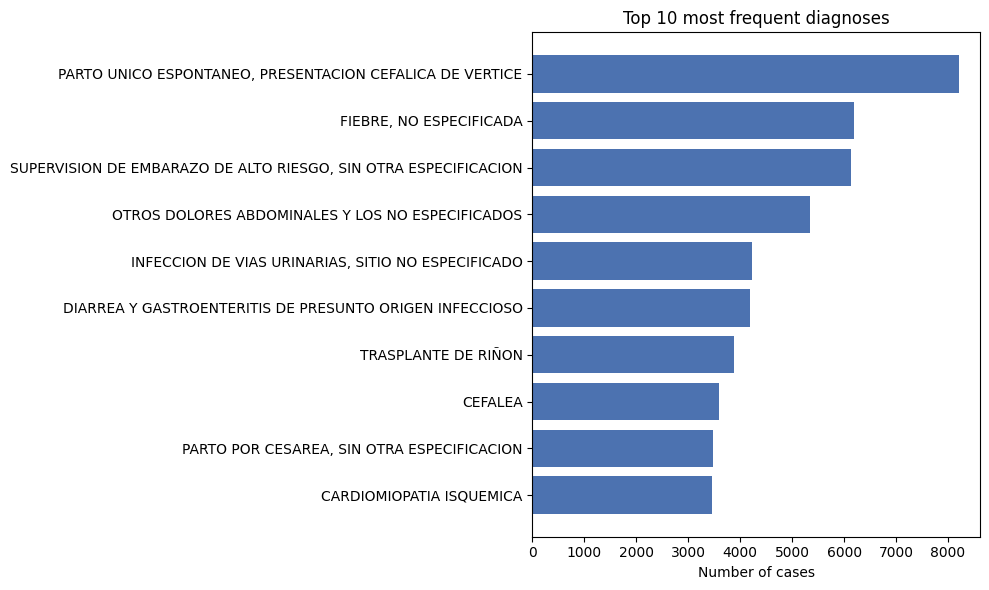

In [135]:
# Take the 10 most frequent diagnoses and sort them ascending (for a horizontal bar chart)
top10 = df["NOMBRE DEL DIAGNOSTICO"].value_counts().head(10).sort_values()

# Create a figure and a single axis with a fixed size
fig, ax = plt.subplots(figsize=(10, 6))
# Draw a horizontal bar chart: category labels on the y-axis, counts on the x-axis
ax.barh(top10.index, top10.values, color="#4C72B0")
# Label the x-axis
ax.set_xlabel("Number of cases")
# Set the chart title
ax.set_title("Top 10 most frequent diagnoses")
# Adjust subplot spacing so labels are not cut off
plt.tight_layout()
# Render the figure
plt.show()

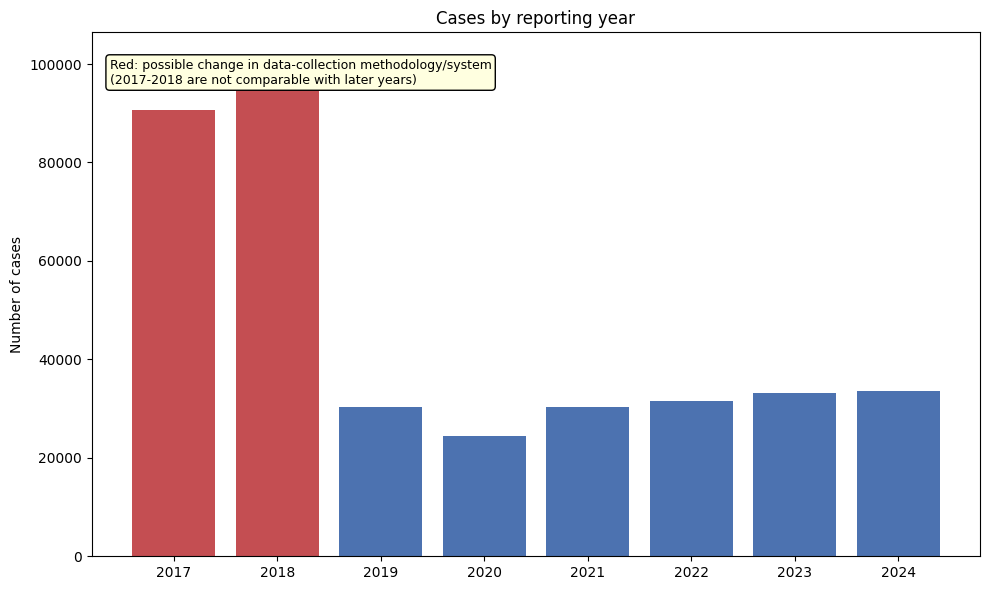

In [136]:
# Recompute the yearly counts (kept independent from earlier variables for clarity)
por_año = df["AÑO REPORTADO"].value_counts().sort_index()

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))
# Highlight 2017-2018 in red and every other year in blue, to flag the anomaly visually
colores = ["#C44E52" if año in [2017, 2018] else "#4C72B0" for año in por_año.index]
# Draw a vertical bar chart of encounters per year, using the color list above
ax.bar(por_año.index.astype(str), por_año.values, color=colores)
# Label the y-axis
ax.set_ylabel("Number of cases")
# Set the chart title
ax.set_title("Cases by reporting year")
# Add an annotation box explaining what the red bars mean
ax.text(0.02, 0.95, "Red: possible change in data-collection methodology/system\n(2017-2018 are not comparable with later years)",
        transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow"))
# Adjust subplot spacing
plt.tight_layout()
# Render the figure
plt.show()

**Interpretation:** a higher number of cases is observed for 2017 and 2018, but this is determined to be a likely data-collection or reporting error, so these two years should be excluded from the substantive analysis of the phenomenon.

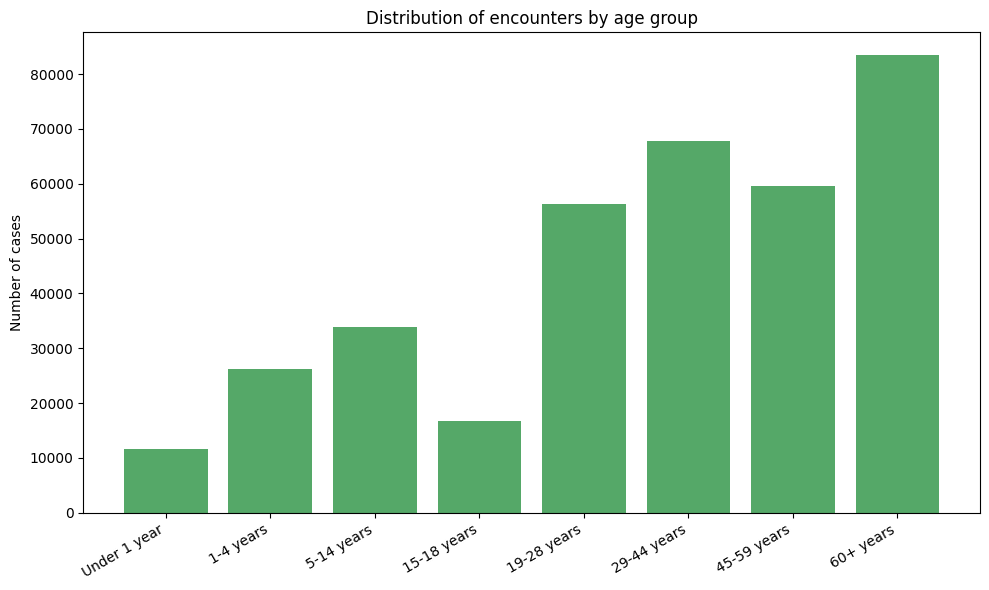

In [137]:
# Count encounters per age group, sorted in the natural (ordinal) order
casos_por_edad = df["GRUPO_ETARIO"].value_counts().sort_index()

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))
# Draw a vertical bar chart of encounters per age group
ax.bar(casos_por_edad.index.astype(str), casos_por_edad.values, color="#55A868")
# Label the y-axis
ax.set_ylabel("Number of cases")
# Set the chart title
ax.set_title("Distribution of encounters by age group")
# Rotate the x-axis labels for readability
plt.xticks(rotation=30, ha="right")
# Adjust subplot spacing
plt.tight_layout()
# Render the figure
plt.show()

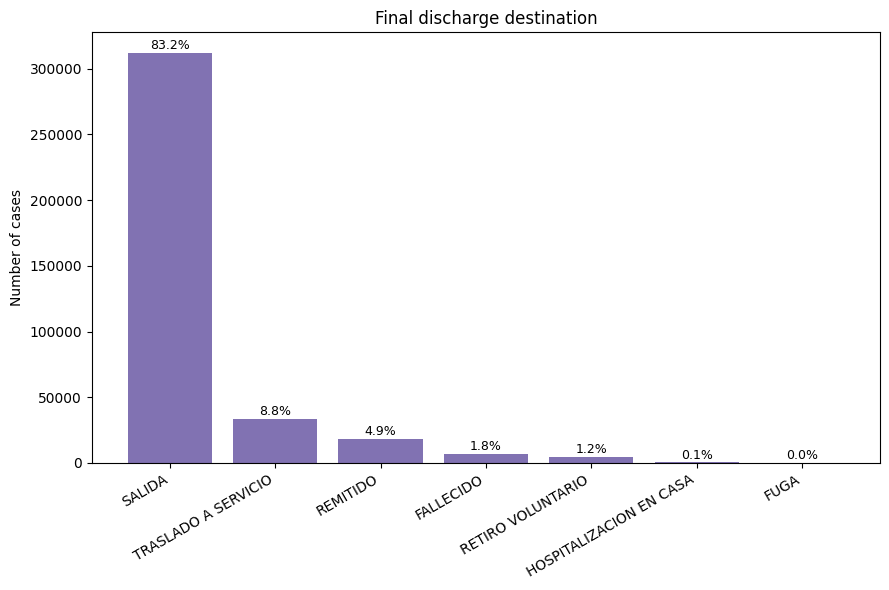

In [138]:
# Frequency of each final discharge destination
destino = df["DESTINO_FINAL"].value_counts()

# Create the figure and axis
fig, ax = plt.subplots(figsize=(9, 6))
# Draw a vertical bar chart of the final discharge destination
ax.bar(destino.index.astype(str), destino.values, color="#8172B2")
# Label the y-axis
ax.set_ylabel("Number of cases")
# Set the chart title
ax.set_title("Final discharge destination")
# Rotate the x-axis labels for readability
plt.xticks(rotation=30, ha="right")

# Annotate the percentage of the total on top of each bar
for i, valor in enumerate(destino.values):
    ax.text(i, valor + 3000, f"{valor/len(df):.1%}", ha="center", fontsize=9)

# Adjust subplot spacing
plt.tight_layout()
# Render the figure
plt.show()

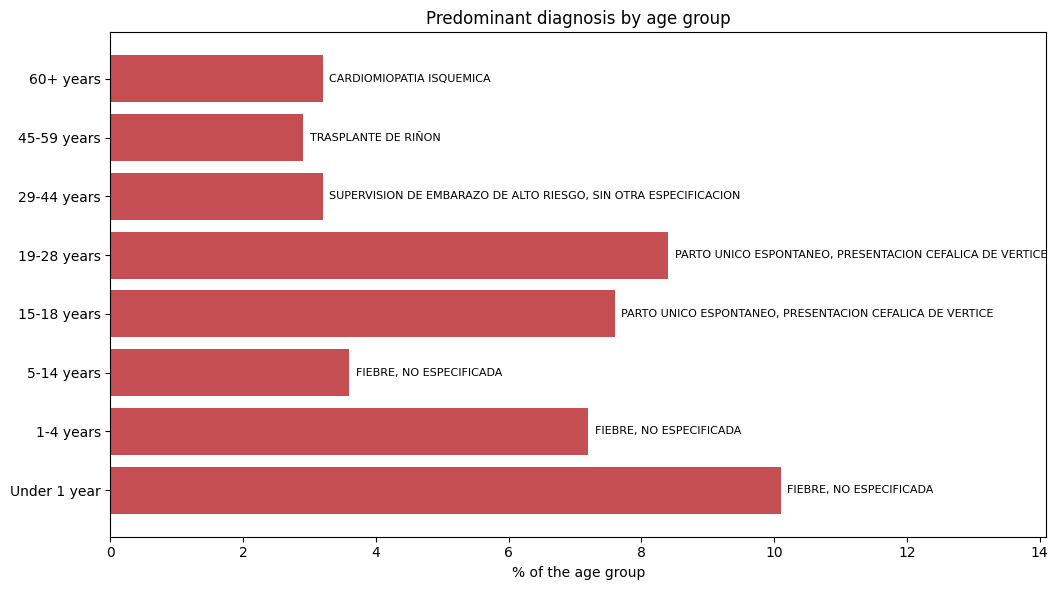

In [139]:
# For each age group, keep only the row with the highest percentage (its top diagnosis)
top1_por_grupo = tabla_46.sort_values("PORCENTAJE", ascending=False).groupby("GRUPO_ETARIO").first()
# Reindex to restore the natural (ordinal) age-group order
top1_por_grupo = top1_por_grupo.reindex(df["GRUPO_ETARIO"].cat.categories)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(11, 6))
# Draw a horizontal bar chart of the top diagnosis share (%) per age group
ax.barh(top1_por_grupo.index.astype(str), top1_por_grupo["PORCENTAJE"], color="#C44E52")
# Annotate each bar with the name of its predominant diagnosis
for i, (pct, diag) in enumerate(zip(top1_por_grupo["PORCENTAJE"], top1_por_grupo["DIAGNOSTICO"])):
    ax.text(pct + 0.1, i, diag, va="center", fontsize=8)
# Label the x-axis
ax.set_xlabel("% of the age group")
# Set the chart title
ax.set_title("Predominant diagnosis by age group")
# Extend the x-axis limit slightly so the text annotations are not clipped
ax.set_xlim(0, top1_por_grupo["PORCENTAJE"].max() + 4)
# Adjust subplot spacing
plt.tight_layout()
# Render the figure
plt.show()

## 7. Conclusions

1. **Data quality drives analytical validity.** The raw dataset contained a mislabeled column, a text-formatted year field, and 94 overlapping categories in *Discharge Destination*. Correcting these issues before analysis was essential; skipping this step would have produced misleading frequency counts (e.g., undercounting deaths, since `FALLECIDO` and `MORGUE` were originally two separate categories referring to the same outcome).

2. **Age is the strongest driver of the morbidity profile observed in this dataset.** The relationship between *age group* and *predominant diagnosis* clearly follows a "life-cycle extremes" pattern: infectious disease in early childhood, maternal-perinatal conditions in reproductive age, and cardiovascular disease in older adulthood (60+ years), which is also the single largest age group by volume of encounters.

3. **2017-2018 should be treated as a separate reporting period.** The abnormally high case counts for these two years, compared with the stable trend from 2019-2024, strongly suggest a change in the data-collection or registration system rather than a real increase in morbidity. Any year-over-year trend analysis should therefore exclude or clearly flag these two years.

4. **Diagnostic dispersion limits single-disease narratives.** With 6,317 distinct ICD-10 codes and no diagnosis exceeding 10% of its age group, the institution's morbidity burden is highly heterogeneous. Conclusions about "the leading cause of X" must always be reported together with their percentage share, to avoid overstating the weight of any single diagnosis.

5. **The absence of a patient identifier is a structural limitation, not a data-cleaning error.** Duplicate rows were intentionally kept rather than removed, since removing them could have deleted legitimate repeat encounters. This decision was made explicit and documented for transparency and reproducibility.

6. **The workflow is fully reproducible.** Every transformation (renaming, type casting, category unification, feature engineering) was implemented with pandas operations that can be re-run on any updated extract of the same dataset, producing consistent results as long as the source column names remain stable.


## 8. Final Health Data Visualization Report

### 8.1 Dataset and variables

**Source:** *Perfil de Morbilidad* (Morbidity Profile), 375,276 records, published on the open data repository (Digital, 2026). Each row represents one patient encounter at a health institution.

The two variables selected as the core of this analysis are:

| Variable | Type | Description |
|---|---|---|
| **Age group** (`GRUPO_ETARIO`) | Ordinal categorical, derived from `EDAD DE ATENCION (AÑOS)` | The patient's age at the time of care, binned into eight clinically meaningful ranges: under 1, 1-4, 5-14, 15-18, 19-28, 29-44, 45-59, and 60+ years. |
| **Diagnosis** (`NOMBRE DEL DIAGNOSTICO`) | Nominal categorical | The clinical diagnosis assigned to the encounter, based on the ICD-10 classification (`CODIGO CIE-10`). |

A secondary variable, **final discharge destination** (`DESTINO_FINAL`), derived from the raw *Discharge Destination* field, was used to complement the analysis with an outcome perspective (mortality and referral rates).

### 8.2 Relationship between the variables

The central question addressed is: *does the predominant type of diagnosis change systematically across age groups?* To answer it, encounters were grouped by age group, and within each group the most frequent diagnoses (and their percentage share) were computed. This turns a categorical-vs-categorical relationship into a comparable set of proportions that can be visualized directly.

The analysis shows that the relationship is not random: each age group has a distinct clinical profile, consistent with well-known epidemiological patterns (pediatric infectious disease, maternal-perinatal care in reproductive age, chronic and cardiovascular disease in older adulthood). This confirms that age group is a meaningful predictor of the type of care demanded from the institution, which has direct implications for resource planning (staffing, equipment, and specialty allocation) by age segment.

### 8.3 Graphical interpretation

- **Top 10 diagnoses (horizontal bar chart):** shows which conditions consume the largest share of overall institutional attention, independent of age. It provides the baseline against which age-specific patterns are compared.
- **Cases by reporting year (bar chart, 2017-2018 highlighted in red):** exposes a likely data-collection artifact in the earliest two years of the series, which must be excluded from trend interpretation.
- **Distribution of encounters by age group (bar chart):** shows that encounters concentrate heavily in the 60+ and 29-44 age groups, establishing where the institution's caseload is concentrated.
- **Final discharge destination (bar chart with % labels):** quantifies clinical outcomes (regular discharge, death, referral, internal transfer, etc.) as a share of all encounters, giving an outcome-level view of the dataset.
- **Predominant diagnosis by age group (horizontal bar chart with diagnosis labels):** is the key chart for this report's core relationship — it directly visualizes, for every age group, which diagnosis is most common and what percentage of that group it represents, making the life-cycle pattern immediately visible.

### 8.4 Findings

- Institutional attention is concentrated: the top 5 functional units account for a majority of all encounters.
- 2017-2018 record counts are anomalously high and are attributed to a probable change in the data-collection system rather than a genuine increase in morbidity.
- Encounters increase sharply in the 60+ age group (83,442 cases, the largest of all groups) and are also notably high in the 29-44 range.
- The registered mortality rate and referral rate, computed from the standardized `DESTINO_FINAL` column, provide a clean outcome baseline that was previously obscured by 94 overlapping raw categories.
- The predominant-diagnosis-by-age-group analysis reveals a clear "life-cycle extremes" pattern (pediatric infections, maternal-perinatal care, and cardiovascular disease in older adults), while also showing that no single diagnosis dominates any group (all shares below 10%), reflecting high diagnostic dispersion (6,317 distinct ICD-10 codes).

### 8.5 Limitations

- No unique patient identifier is available, so duplicate rows cannot be conclusively classified as data-entry errors or genuine repeat encounters.
- "Unspecified fever" in pediatric groups likely reflects under-registration of the definitive diagnosis rather than a true predominant condition.
- 2017-2018 figures are not directly comparable to later years and were excluded from trend-related conclusions.


## 9. Reproducibility and ethics statement

**Reproducibility.** This notebook was built to be re-run end-to-end on the same source file (`Perfil_de_morbilidad_20260906.csv`) or on any future extract that preserves the same column names. All transformations are deterministic pandas operations (renaming, type casting, category mapping, binning) with no random components, so results are fully reproducible. Every processing decision is documented immediately after the corresponding code cell, in technical English, so that engineers unfamiliar with the original language of the raw data (Spanish column names and category labels) can understand, audit, and extend the workflow.

**Ethics.** The dataset does not include direct patient identifiers (name, national ID, or medical record number), which reduces re-identification risk; however, it does contain diagnosis, age, and discharge outcome, which are sensitive health attributes. For this reason:

- No attempt was made to link records across the dataset to reconstruct individual patient histories.
- Duplicate rows were deliberately **not** deleted, since doing so could silently remove legitimate clinical cases and bias the reported frequencies — a transparent, documented decision was preferred over a silent one.
- All findings are reported at the aggregate (group) level; no individual record is singled out or presented in isolation.
- Conclusions about mortality and morbidity are framed as descriptive statistics of this specific dataset and time window, not as generalizable clinical or epidemiological claims beyond the reporting institution and period covered.


## 10. References

- Datos Abiertos Colombia. (2026). *ENFERMEDADES* [Data set]. https://www.datos.gov.co/Salud-y-Protecci-n-Social/ENFERMEDADES/5r4m-umt6

- pandas development team. (2026). *pandas documentation*. https://pandas.pydata.org/docs/

- Matplotlib development team. (2026). *Matplotlib documentation*. https://matplotlib.org/stable/---